Project Title: Flight Block Time Forecasting & Schedule Reliability Optimization

Project objective

Business question:

Can we predict actual flight block time and recommend schedule buffer adjustments that improve on-time reliability without adding unnecessary scheduled minutes?

In simple terms:

Too little block time → flights arrive late, bad reliability.

Too much block time → aircraft utilization drops, schedule becomes inefficient.

The goal is to find the right balance.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

The Dataset is from Bureau of Transportation Statistics for Three months of October, November and December for the year 2025

In [8]:
from google.colab import files

uploaded = files.upload()

Saving T_ONTIME_REPORTING OCT 2025.csv to T_ONTIME_REPORTING OCT 2025 (1).csv
Saving T_ONTIME_REPORTING NOV 2025.csv to T_ONTIME_REPORTING NOV 2025.csv
Saving T_ONTIME_REPORTING DEC 2025.csv to T_ONTIME_REPORTING DEC 2025 (1).csv


In [5]:
os.listdir()

['.config',
 'T_ONTIME_REPORTING 2 NOV 2025.csv',
 'T_ONTIME_REPORTING DEC 2025.csv',
 'T_ONTIME_REPORTING OCT 2025.csv',
 'sample_data']

Combining all three dataset in one.

In [9]:
files_list = [
    "T_ONTIME_REPORTING OCT 2025.csv",
    "T_ONTIME_REPORTING NOV 2025.csv",
    "T_ONTIME_REPORTING DEC 2025.csv"
]

df_list = []

for file in files_list:
    temp = pd.read_csv(file, low_memory=False)
    temp["source_file"] = file
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Combined shape:", df.shape)
df.head()

Combined shape: (119842, 34)


,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,source_file
0,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,1394,DCA,...,159.0,152.0,125.0,857.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv
1,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,1394,PBI,...,140.0,146.0,114.0,857.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv
2,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,2040,DCA,...,107.0,113.0,59.0,331.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv
3,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,527,CLT,...,85.0,80.0,53.0,331.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv
4,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N114UW,1269,CLT,...,87.0,70.0,53.0,331.0,25.0,0.0,0.0,0.0,0.0,T_ONTIME_REPORTING OCT 2025.csv


In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

df.columns.tolist()

['year',
 'quarter',
 'month',
 'day_of_month',
 'day_of_week',
 'fl_date',
 'op_unique_carrier',
 'tail_num',
 'op_carrier_fl_num',
 'origin',
 'dest',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'dep_delay_new',
 'taxi_out',
 'taxi_in',
 'crs_arr_time',
 'arr_time',
 'arr_delay',
 'arr_delay_new',
 'arr_del15',
 'cancelled',
 'diverted',
 'crs_elapsed_time',
 'actual_elapsed_time',
 'air_time',
 'distance',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay',
 'source_file']

In [11]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 119842
Columns: 34
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119842 entries, 0 to 119841
Data columns (total 34 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 119842 non-null  int64  
 1   quarter              119842 non-null  int64  
 2   month                119842 non-null  int64  
 3   day_of_month         119842 non-null  int64  
 4   day_of_week          119842 non-null  int64  
 5   fl_date              119842 non-null  object 
 6   op_unique_carrier    119842 non-null  object 
 7   tail_num             119642 non-null  object 
 8   op_carrier_fl_num    119842 non-null  int64  
 9   origin               119842 non-null  object 
 10  dest                 119842 non-null  object 
 11  crs_dep_time         119842 non-null  int64  
 12  dep_time             117855 non-null  float64
 13  dep_delay            117852 non-null  float64
 14  dep_delay_new        117852 non-null  float

In [12]:
df["month"].value_counts().sort_index()

,count
month,
10,41698
11,39294
12,38850


These are all the different Airlines, I'll do this project for American Airlines

In [13]:
df["op_unique_carrier"].value_counts().head(10)

,count
op_unique_carrier,
YX,22627
UA,21959
OH,21348
AA,17946
WN,11374
DL,9789
B6,4676
OO,3058
MQ,2716


In [14]:
df_completed = df[
    (df["cancelled"] == 0) &
    (df["diverted"] == 0)
].copy()

print("Completed flights:", df_completed.shape)

Completed flights: (117590, 34)


In [15]:
key_cols = [
    "origin",
    "dest",
    "crs_dep_time",
    "crs_elapsed_time",
    "actual_elapsed_time",
    "arr_delay",
    "arr_del15",
    "dep_delay",
    "taxi_out",
    "taxi_in",
    "distance"
]

df_completed = df_completed.dropna(subset=key_cols)

print("After dropping missing values:", df_completed.shape)

After dropping missing values: (117590, 34)


In [16]:
df_aa = df_completed[df_completed["op_unique_carrier"] == "AA"].copy()

print("AA completed flights:", df_aa.shape)
df_aa.head()

AA completed flights: (17748, 34)


,year,quarter,month,day_of_month,day_of_week,fl_date,op_unique_carrier,tail_num,op_carrier_fl_num,origin,...,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,source_file
0,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,1394,DCA,...,159.0,152.0,125.0,857.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv
1,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,1394,PBI,...,140.0,146.0,114.0,857.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv
2,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,2040,DCA,...,107.0,113.0,59.0,331.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv
3,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,527,CLT,...,85.0,80.0,53.0,331.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv
4,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N114UW,1269,CLT,...,87.0,70.0,53.0,331.0,25.0,0.0,0.0,0.0,0.0,T_ONTIME_REPORTING OCT 2025.csv


In [17]:
df_aa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17748 entries, 0 to 118947
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 17748 non-null  int64  
 1   quarter              17748 non-null  int64  
 2   month                17748 non-null  int64  
 3   day_of_month         17748 non-null  int64  
 4   day_of_week          17748 non-null  int64  
 5   fl_date              17748 non-null  object 
 6   op_unique_carrier    17748 non-null  object 
 7   tail_num             17748 non-null  object 
 8   op_carrier_fl_num    17748 non-null  int64  
 9   origin               17748 non-null  object 
 10  dest                 17748 non-null  object 
 11  crs_dep_time         17748 non-null  int64  
 12  dep_time             17748 non-null  float64
 13  dep_delay            17748 non-null  float64
 14  dep_delay_new        17748 non-null  float64
 15  taxi_out             17748 non-null  flo

In [18]:
df_aa["month"].value_counts().sort_index()

,count
month,
10,6483
11,5631
12,5634


Block Time and Reliability Features

In [19]:
df_aa["route"] = df_aa["origin"] + "-" + df_aa["dest"]

df_aa["dep_hour"] = (df_aa["crs_dep_time"] // 100).astype(int)

df_aa["block_time_error"] = (
    df_aa["actual_elapsed_time"] - df_aa["crs_elapsed_time"]
)

df_aa["underblocked"] = np.where(
    df_aa["block_time_error"] > 0, 1, 0
)

df_aa["late_arrival"] = np.where(
    df_aa["arr_delay"] > 15, 1, 0
)

df_aa["is_weekend"] = df_aa["day_of_week"].isin([6, 7]).astype(int)

df_aa[[
    "fl_date", "op_unique_carrier", "origin", "dest", "route",
    "crs_elapsed_time", "actual_elapsed_time", "block_time_error",
    "arr_delay", "late_arrival"
]].head()

,fl_date,op_unique_carrier,origin,dest,route,crs_elapsed_time,actual_elapsed_time,block_time_error,arr_delay,late_arrival
0,10/1/2025 12:00:00 AM,AA,DCA,PBI,DCA-PBI,159.0,152.0,-7.0,-16.0,0
1,10/1/2025 12:00:00 AM,AA,PBI,DCA,PBI-DCA,140.0,146.0,6.0,0.0,0
2,10/1/2025 12:00:00 AM,AA,DCA,CLT,DCA-CLT,107.0,113.0,6.0,0.0,0
3,10/1/2025 12:00:00 AM,AA,CLT,DCA,CLT-DCA,85.0,80.0,-5.0,-11.0,0
4,10/1/2025 12:00:00 AM,AA,CLT,DCA,CLT-DCA,87.0,70.0,-17.0,25.0,1


block_time_error: actual block time minus scheduled block time

Positive value means the flight took longer than scheduled

underblocked: 1 if actual block time exceeded scheduled block time

late_arrival: 1 if arrival delay was more than 15 minutes

In [20]:
df_aa

,year,quarter,month,day_of_month,day_of_week,fl_date,op_unique_carrier,tail_num,op_carrier_fl_num,origin,...,nas_delay,security_delay,late_aircraft_delay,source_file,route,dep_hour,block_time_error,underblocked,late_arrival,is_weekend
0,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,1394,DCA,...,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv,DCA-PBI,8,-7.0,0,0,0
1,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,1394,PBI,...,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv,PBI-DCA,12,6.0,1,0,0
2,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,2040,DCA,...,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv,DCA-CLT,15,6.0,1,0,0
3,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,527,CLT,...,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv,CLT-DCA,18,-5.0,0,0,0
4,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N114UW,1269,CLT,...,0.0,0.0,0.0,T_ONTIME_REPORTING OCT 2025.csv,CLT-DCA,21,-17.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118943,2025,4,12,31,3,12/31/2025 12:00:00 AM,AA,N987AN,772,ORD,...,0.0,0.0,34.0,T_ONTIME_REPORTING DEC 2025.csv,ORD-DCA,13,-10.0,0,1,0
118944,2025,4,12,31,3,12/31/2025 12:00:00 AM,AA,N989AU,2752,DFW,...,0.0,0.0,46.0,T_ONTIME_REPORTING DEC 2025.csv,DFW-DCA,19,-4.0,0,1,0
118945,2025,4,12,31,3,12/31/2025 12:00:00 AM,AA,N991NN,472,DFW,...,NaN,NaN,NaN,T_ONTIME_REPORTING DEC 2025.csv,DFW-DCA,17,4.0,1,0,0
118946,2025,4,12,31,3,12/31/2025 12:00:00 AM,AA,N993NN,2368,DCA,...,NaN,NaN,NaN,T_ONTIME_REPORTING DEC 2025.csv,DCA-MIA,19,-25.0,0,0,0


Route Level Summary

In [21]:
route_summary = (
    df_aa.groupby("route", as_index=False)
    .agg(
        flights=("route", "count"),
        avg_scheduled_block=("crs_elapsed_time", "mean"),
        avg_actual_block=("actual_elapsed_time", "mean"),
        avg_block_error=("block_time_error", "mean"),
        median_block_error=("block_time_error", "median"),
        p75_block_error=("block_time_error", lambda x: np.percentile(x, 75)),
        p90_block_error=("block_time_error", lambda x: np.percentile(x, 90)),
        late_rate=("late_arrival", "mean"),
        avg_arrival_delay=("arr_delay", "mean"),
        avg_departure_delay=("dep_delay", "mean"),
        avg_taxi_out=("taxi_out", "mean"),
        avg_taxi_in=("taxi_in", "mean"),
        distance=("distance", "mean")
    )
)

route_summary["late_rate"] = route_summary["late_rate"] * 100

route_summary = route_summary.sort_values(
    ["late_rate", "flights"],
    ascending=[False, False]
)

route_summary.head(15)

,route,flights,avg_scheduled_block,avg_actual_block,avg_block_error,median_block_error,p75_block_error,p90_block_error,late_rate,avg_arrival_delay,avg_departure_delay,avg_taxi_out,avg_taxi_in,distance
54,DTW-DCA,3,100.000000,95.000000,-5.000000,-22.0,4.50,20.4,66.666667,171.000000,176.000000,21.666667,9.666667,405.0
1,BDL-DCA,47,84.021277,81.425532,-2.595745,-7.0,1.50,11.8,42.553191,37.957447,40.553191,16.787234,5.723404,313.0
13,DCA-BDL,48,85.166667,79.729167,-5.437500,-8.0,0.00,4.6,39.583333,38.458333,43.895833,22.229167,5.729167,313.0
16,DCA-BOS,626,95.062300,95.746006,0.683706,-3.0,6.00,18.0,35.782748,25.078275,24.394569,23.453674,6.950479,399.0
8,CLT-DCA,595,84.191597,88.420168,4.228571,1.0,15.00,28.6,35.630252,15.490756,11.262185,29.526050,5.512605,331.0
15,DCA-BNA,89,120.775281,120.898876,0.123596,-2.0,7.00,14.0,34.831461,17.011236,16.887640,19.224719,7.651685,562.0
46,DCA-SYR,49,84.571429,78.469388,-6.102041,-9.0,1.00,7.0,34.693878,15.673469,21.775510,23.224490,4.551020,298.0
87,SYR-DCA,49,85.122449,89.163265,4.040816,1.0,10.00,29.4,34.693878,23.285714,19.244898,21.714286,6.448980,298.0
22,DCA-DTW,3,96.333333,114.666667,18.333333,-3.0,29.50,49.0,33.333333,129.333333,111.000000,13.666667,36.666667,405.0
81,RIC-DFW,264,209.564394,210.553030,0.988636,-3.0,8.00,23.0,32.196970,17.965909,16.977273,17.545455,16.162879,1158.0


Routes with minimum 30 flights

In [22]:
route_summary_30 = route_summary[route_summary["flights"] >= 30].copy()

route_summary_30.head(15)

,route,flights,avg_scheduled_block,avg_actual_block,avg_block_error,median_block_error,p75_block_error,p90_block_error,late_rate,avg_arrival_delay,avg_departure_delay,avg_taxi_out,avg_taxi_in,distance
1,BDL-DCA,47,84.021277,81.425532,-2.595745,-7.0,1.50,11.8,42.553191,37.957447,40.553191,16.787234,5.723404,313.0
13,DCA-BDL,48,85.166667,79.729167,-5.437500,-8.0,0.00,4.6,39.583333,38.458333,43.895833,22.229167,5.729167,313.0
16,DCA-BOS,626,95.062300,95.746006,0.683706,-3.0,6.00,18.0,35.782748,25.078275,24.394569,23.453674,6.950479,399.0
8,CLT-DCA,595,84.191597,88.420168,4.228571,1.0,15.00,28.6,35.630252,15.490756,11.262185,29.526050,5.512605,331.0
15,DCA-BNA,89,120.775281,120.898876,0.123596,-2.0,7.00,14.0,34.831461,17.011236,16.887640,19.224719,7.651685,562.0
46,DCA-SYR,49,84.571429,78.469388,-6.102041,-9.0,1.00,7.0,34.693878,15.673469,21.775510,23.224490,4.551020,298.0
87,SYR-DCA,49,85.122449,89.163265,4.040816,1.0,10.00,29.4,34.693878,23.285714,19.244898,21.714286,6.448980,298.0
81,RIC-DFW,264,209.564394,210.553030,0.988636,-3.0,8.00,23.0,32.196970,17.965909,16.977273,17.545455,16.162879,1158.0
56,FLL-DCA,156,149.506410,145.730769,-3.775641,-6.0,1.00,10.0,32.051282,16.147436,19.923077,18.891026,5.384615,899.0
86,STL-DCA,32,121.875000,121.593750,-0.281250,-3.0,6.25,12.9,31.250000,15.562500,15.843750,16.718750,6.031250,719.0


In [23]:
top_late_routes = route_summary_30.sort_values(
    "late_rate",
    ascending=False
).head(15)

top_late_routes[[
    "route", "flights", "late_rate", "avg_block_error",
    "avg_departure_delay", "avg_taxi_out", "avg_arrival_delay"
]]

,route,flights,late_rate,avg_block_error,avg_departure_delay,avg_taxi_out,avg_arrival_delay
1,BDL-DCA,47,42.553191,-2.595745,40.553191,16.787234,37.957447
13,DCA-BDL,48,39.583333,-5.437500,43.895833,22.229167,38.458333
16,DCA-BOS,626,35.782748,0.683706,24.394569,23.453674,25.078275
8,CLT-DCA,595,35.630252,4.228571,11.262185,29.526050,15.490756
15,DCA-BNA,89,34.831461,0.123596,16.887640,19.224719,17.011236
46,DCA-SYR,49,34.693878,-6.102041,21.775510,23.224490,15.673469
87,SYR-DCA,49,34.693878,4.040816,19.244898,21.714286,23.285714
81,RIC-DFW,264,32.196970,0.988636,16.977273,17.545455,17.965909
56,FLL-DCA,156,32.051282,-3.775641,19.923077,18.891026,16.147436
86,STL-DCA,32,31.250000,-0.281250,15.843750,16.718750,15.562500


Above are the routes with highest late arrival rates

Below are the routes which are underblocked that means these routes have actual block times higher than scheduled block times

In [24]:
underblocked_routes = route_summary_30.sort_values(
    "avg_block_error",
    ascending=False
).head(15)

underblocked_routes[[
    "route", "flights", "avg_scheduled_block", "avg_actual_block",
    "avg_block_error", "late_rate"
]]

,route,flights,avg_scheduled_block,avg_actual_block,avg_block_error,late_rate
8,CLT-DCA,595,84.191597,88.420168,4.228571,35.630252
87,SYR-DCA,49,85.122449,89.163265,4.040816,34.693878
77,PVD-DCA,113,91.247788,92.725664,1.477876,22.123894
81,RIC-DFW,264,209.564394,210.553030,0.988636,32.196970
16,DCA-BOS,626,95.062300,95.746006,0.683706,35.782748
15,DCA-BNA,89,120.775281,120.898876,0.123596,34.831461
79,RDU-DCA,48,67.770833,67.833333,0.062500,14.583333
86,STL-DCA,32,121.875000,121.593750,-0.281250,31.250000
70,ORD-DCA,534,114.720974,113.765918,-0.955056,28.464419
2,BGR-DCA,62,114.629032,113.661290,-0.967742,17.741935


Routes that are late but not underbloacked, that means some routes have high late-arrival rates even though scheduled block time is not too low. That suggests the root cause may be departure delay, taxi-out congestion, late aircraft, or NAS delay rather than block-time planning alone.

In [25]:
late_not_underblocked = route_summary_30[
    (route_summary_30["late_rate"] >= 25) &
    (route_summary_30["avg_block_error"] <= 0)
].sort_values("late_rate", ascending=False)

late_not_underblocked[[
    "route", "flights", "late_rate", "avg_block_error",
    "avg_departure_delay", "avg_taxi_out", "avg_arrival_delay"
]].head(15)

,route,flights,late_rate,avg_block_error,avg_departure_delay,avg_taxi_out,avg_arrival_delay
1,BDL-DCA,47,42.553191,-2.595745,40.553191,16.787234,37.957447
13,DCA-BDL,48,39.583333,-5.437500,43.895833,22.229167,38.458333
46,DCA-SYR,49,34.693878,-6.102041,21.775510,23.224490,15.673469
56,FLL-DCA,156,32.051282,-3.775641,19.923077,18.891026,16.147436
86,STL-DCA,32,31.250000,-0.281250,15.843750,16.718750,15.562500
51,DFW-IAD,197,30.964467,-5.868020,20.152284,18.832487,14.284264
52,DFW-ORF,219,30.593607,-8.050228,23.716895,17.493151,15.666667
85,SRQ-DCA,82,30.487805,-3.280488,27.036585,19.573171,23.756098
26,DCA-JAX,238,29.411765,-4.487395,17.100840,20.411765,12.613445
45,DCA-STL,31,29.032258,-6.709677,40.000000,20.032258,33.290323


Analyzing reliability by departure hour

In [26]:
hourly_reliability = (
    df_aa.groupby("dep_hour", as_index=False)
    .agg(
        flights=("dep_hour", "count"),
        late_rate=("late_arrival", "mean"),
        avg_block_error=("block_time_error", "mean"),
        avg_departure_delay=("dep_delay", "mean"),
        avg_taxi_out=("taxi_out", "mean")
    )
)

hourly_reliability["late_rate"] *= 100

hourly_reliability

,dep_hour,flights,late_rate,avg_block_error,avg_departure_delay,avg_taxi_out
0,0,54,9.259259,-4.222222,3.333333,14.425926
1,5,558,9.677419,-6.806452,8.795699,15.896057
2,6,1756,12.528474,-4.471526,4.727790,18.522779
3,7,1076,14.498141,-5.393123,5.344796,20.403346
4,8,1367,17.995611,-3.649598,9.226774,24.651061
5,9,733,18.008186,-5.669850,8.649386,20.069577
6,10,1287,17.327117,-9.188811,12.851593,19.975913
7,11,1186,23.355818,-4.198988,17.582631,18.564924
8,12,738,24.796748,-4.967480,18.227642,19.239837
9,13,977,25.997953,-4.484135,14.954964,19.175026


Plotting top late routes

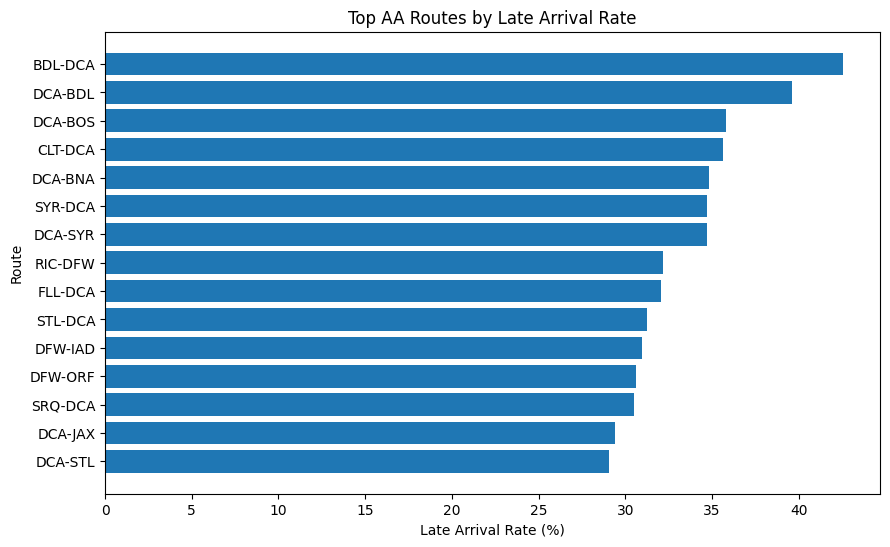

In [27]:
top_plot = top_late_routes.sort_values("late_rate", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_plot["route"], top_plot["late_rate"])
plt.xlabel("Late Arrival Rate (%)")
plt.ylabel("Route")
plt.title("Top AA Routes by Late Arrival Rate")
plt.show()

Plotting block-time error distribution

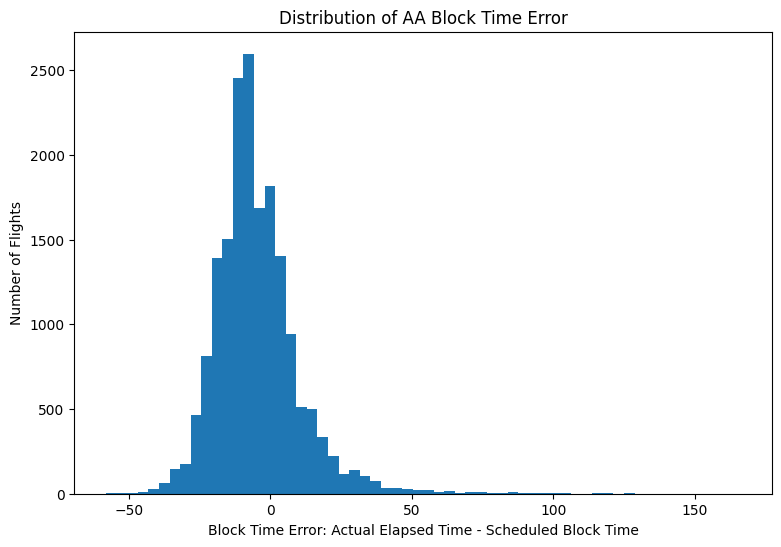

In [28]:
plt.figure(figsize=(9, 6))
plt.hist(df_aa["block_time_error"], bins=60)
plt.xlabel("Block Time Error: Actual Elapsed Time - Scheduled Block Time")
plt.ylabel("Number of Flights")
plt.title("Distribution of AA Block Time Error")
plt.show()

Plotting late rate by departure hour

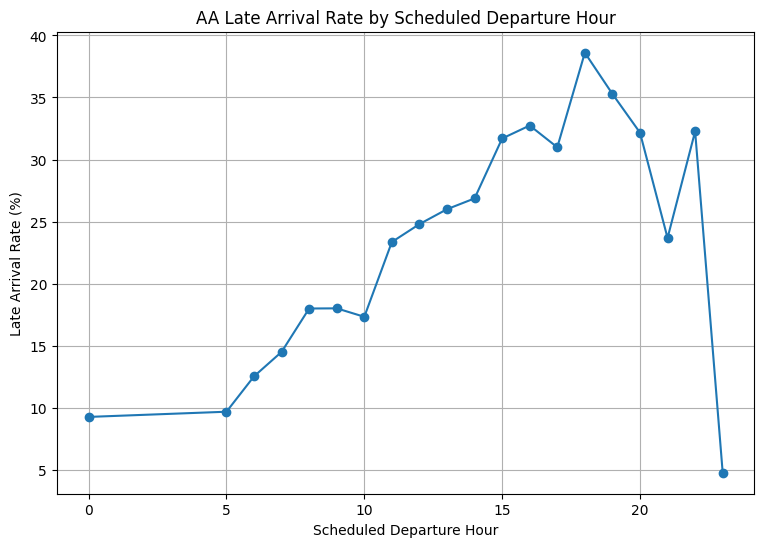

In [29]:
plt.figure(figsize=(9, 6))
plt.plot(hourly_reliability["dep_hour"], hourly_reliability["late_rate"], marker="o")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Late Arrival Rate (%)")
plt.title("AA Late Arrival Rate by Scheduled Departure Hour")
plt.grid(True)
plt.show()

Creating first schedule buffer recommendation table i.e. the first decision-support output

In [30]:
recommendations = route_summary_30.copy()

recommendations["recommended_action"] = np.select(
    [
        (recommendations["avg_block_error"] > 3) & (recommendations["late_rate"] > 25),
        (recommendations["avg_block_error"] < -5) & (recommendations["late_rate"] < 20),
        (recommendations["late_rate"] > 25) & (recommendations["avg_block_error"] <= 0)
    ],
    [
        "Increase block time / review schedule buffer",
        "Potentially reduce excess block time",
        "Investigate operational root causes"
    ],
    default="Monitor"
)

recommendations = recommendations.sort_values(
    ["late_rate", "avg_block_error"],
    ascending=[False, False]
)

recommendations[[
    "route", "flights", "late_rate", "avg_block_error",
    "avg_departure_delay", "avg_taxi_out", "recommended_action"
]].head(20)

,route,flights,late_rate,avg_block_error,avg_departure_delay,avg_taxi_out,recommended_action
1,BDL-DCA,47,42.553191,-2.595745,40.553191,16.787234,Investigate operational root causes
13,DCA-BDL,48,39.583333,-5.437500,43.895833,22.229167,Investigate operational root causes
16,DCA-BOS,626,35.782748,0.683706,24.394569,23.453674,Monitor
8,CLT-DCA,595,35.630252,4.228571,11.262185,29.526050,Increase block time / review schedule buffer
15,DCA-BNA,89,34.831461,0.123596,16.887640,19.224719,Monitor
87,SYR-DCA,49,34.693878,4.040816,19.244898,21.714286,Increase block time / review schedule buffer
46,DCA-SYR,49,34.693878,-6.102041,21.775510,23.224490,Investigate operational root causes
81,RIC-DFW,264,32.196970,0.988636,16.977273,17.545455,Monitor
56,FLL-DCA,156,32.051282,-3.775641,19.923077,18.891026,Investigate operational root causes
86,STL-DCA,32,31.250000,-0.281250,15.843750,16.718750,Investigate operational root causes


Saving and downloading cleaned data and outputs for Modelling i.e. prediction, classification and optimization.

In [31]:
df_aa.to_csv("aa_va_flights_oct_nov_dec_2025_clean.csv", index=False)
route_summary.to_csv("aa_route_summary_oct_nov_dec_2025.csv", index=False)
recommendations.to_csv("aa_schedule_buffer_recommendations.csv", index=False)

In [34]:
from google.colab import files

files.download("aa_va_flights_oct_nov_dec_2025_clean.csv")
files.download("aa_route_summary_oct_nov_dec_2025.csv")
files.download("aa_schedule_buffer_recommendations.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

SUMMARY: I first cleaned BTS on-time performance data for AA flights across Virginia/DC-area routes from October to December 2025. Then I compared scheduled block time against actual elapsed time, calculated route-level block-time error and late-arrival rates, and identified whether reliability issues were caused by underblocked schedules or operational drivers like departure delay and taxi-out congestion.

After this Notebook I have:

1. A cleaned AA flight dataset
2. Route-level block-time summary
3. Top late routes
4. Underblocked routes
5. Late-but-not-underblocked routes
6. Departure-hour reliability analysis
7. First schedule buffer recommendation table
8. Three charts